In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json('/home/snt/projects_lujun/agentCLS/efficiency_LDD.jsonl', lines = True)

/tmp/ipykernel_3872188/1170255922.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_models))  # 使用颜色映射


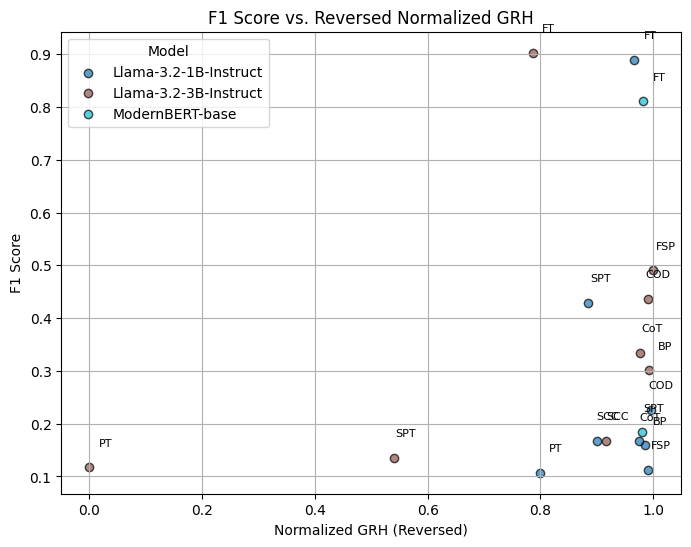

In [ ]:
# 去除无效数据
df = df.dropna()
df["GRH"] = df["GRH"].astype(float)

# 反向归一化 GRH (min-max scaling)
df["GRH_norm"] = 1 - (df["GRH"] - df["GRH"].min()) / (df["GRH"].max() - df["GRH"].min())

method_dict = {
    "Base prompt": "BP",
    "Few-shot Prompt": "FSP",
    "Chain-of-Thought": "CoT",
    "Self-consistency COT": "SCC",
    "Soft Prompt Tuning (SPT)": "SPT",
    "Prefix Tuning (PT)": "PT",
    "Fine-tuning (FT)": "FT",
    "Chain-of-Draft": "COD"
}

# 获取不同模型的颜色
unique_models = df["model"].unique()
colors = plt.cm.get_cmap("tab10", len(unique_models))  # 使用颜色映射

# 绘制散点图
plt.figure(figsize=(8, 6))

# 为每个模型选择不同颜色
for i, model in enumerate(unique_models):
    model_data = df[df["model"] == model]
    plt.scatter(model_data["GRH_norm"], model_data["F1"], alpha=0.7, edgecolors="black", label=model, color=colors(i))

# 标注点
for i, row in df.iterrows():
    plt.text(row["GRH_norm"], row["F1"], method_dict[row["method"]], fontsize=8, ha='right')

plt.xlabel("Normalized GRH (Reversed)")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Reversed Normalized GRH")
plt.grid(True)
plt.legend(title="Model")
plt.savefig("F1_vs_GRH.svg", format="svg")
plt.show()
